# Comparativa de algoritmos APS

## Secuencia de procesamiento de datos

Antes de comparar los algoritmos conviene separar dos cosas: los archivos de entrada que describen el problema APS y los archivos de salida que resumen cada experimento. Los notebooks `aps_genetico.ipynb`, `aps_ensemble.ipynb` y `aps_neuronal.ipynb` construyen sus planificaciones a partir de los mismos datos base; este notebook de comparativa no vuelve a planificar, sino que lee los JSON y CSV ya exportados por esos notebooks.

La secuencia comun de procesamiento es la siguiente:

1. `PLAN.csv` aporta las ordenes que se quieren planificar. De aqui se usan principalmente `ORDEN`, `PARTNUMBER`, `CANTIDAD`, `FECHA_PROVEEDOR`, `FECHA_ENTREGA`, `CENTRO` y `CLIENTE`. Es el archivo que define la demanda: que fabricar, cuanto fabricar y contra que fecha evaluar si la orden termina a tiempo.

2. `CCP.csv` aporta la ruta tecnica de fabricacion por `PARTNUMBER`. De aqui se usan `OPERACION`, `RECURSO`, `TECNOLOGIA`, `CENTRO_MECANIZADO`, `PIEZAS_SIMULTANEAS`, `TIEMPO_FIJO_MIN`, `TIEMPO_VARIABLE_MIN` y `OEE`. Es el archivo que convierte cada orden de `PLAN` en una lista de operaciones planificables. Tambien fija las duraciones mediante la formula comun `(TIEMPO_FIJO_MIN + TIEMPO_VARIABLE_MIN * CANTIDAD / MULTIPLICIDAD) * 100 / OEE`, usando `PIEZAS_SIMULTANEAS` como multiplicidad cuando aplica.

3. `LPA_GAM.csv` y `LPA_GSM.csv` aportan la huella historica de planificacion de Asprova para las dos plantas. No se usan como calendario final a copiar. Se concatenan en un unico `lpa_df` y se usan para reconstruir el entorno real de recursos: que maquinas existen, en que `GRUPO_RECURSO` aparecen, que grupos se observaron para cada combinacion `PARTNUMBER` + `OPERACION`, y cual es la `FECHA_CALCULO_PLAN` inicial usada como referencia temporal del plan. El comienzo de la simulacion no se toma de la primera `COMIENZO_OPERACION` historica; se calcula como la fecha minima de `FECHA_CALCULO_PLAN` en `LPA_GAM` y `LPA_GSM`, redondeada al dia, y despues se ajusta al calendario laboral.

4. Con `PLAN` y `CCP` se filtran las ordenes no planificables: ordenes sin `PARTNUMBER` valido en CCP, rutas con duracion base cero, OEE nulo o cero, o alternativas que no pueden mapearse a un grupo de recurso valido. Este paso evita comparar algoritmos sobre operaciones imposibles o datos incompletos.

5. Con `LPA_GAM` y `LPA_GSM` se genera la tabla de recursos (`RECURSOS.csv`) y el diccionario `recursos_por_grupo`. Este diccionario dice, para cada grupo de recurso, que maquinas concretas puede usar el simulador. Es una restriccion dura para el decodificador de scheduling.

6. Cada orden planificable se transforma en una estructura interna `order_operations`: una secuencia ordenada de operaciones CCP, cada una con alternativas de recurso/grupo y duracion calculada. A partir de ahi, todos los enfoques usan el mismo decodificador `decode_schedule`: dada una permutacion de ordenes, el decodificador coloca sus operaciones respetando precedencias, disponibilidad de recursos, calendario laboral y duraciones CCP.

7. Cada notebook exporta su resultado operativo con estructura compatible con LPA: `ORDEN`, `OPERACION`, `RECURSO`, `PARTNUMBER`, `CANTIDAD`, `COMIENZO_OPERACION`, `FIN_OPERACION`, `TIEMPO_PREPARACION`, `TIEMPO_PROCESO`, `GRUPO_RECURSO`, `MULTIPLICIDAD`, `DURACION_CCP` y `FECHA_CALCULO_PLAN`. Esta compatibilidad permite comparar la salida generada contra el formato tipo Asprova.

## Uso especifico de LPA_GAM y LPA_GSM

`LPA_GAM.csv` y `LPA_GSM.csv` son importantes, pero su papel no es optimizar directamente. Funcionan como memoria de planta. Su uso principal es:

- Construir el inventario real de recursos y grupos. Las apariciones `RECURSO` / `GRUPO_RECURSO` observadas en LPA permiten saber que maquinas pertenecen a cada grupo.
- Inferir el `GRUPO_RECURSO` de registros CCP. Como CCP no siempre trae el grupo final de forma directa, se cruza lo observado historicamente por `PARTNUMBER` y `OPERACION` en LPA. Si Asprova planifico esa combinacion en cierto grupo, ese grupo se usa como referencia compatible.
- Fijar el inicio temporal del experimento. La fecha minima de `FECHA_CALCULO_PLAN` se toma como `PLAN_START`, y desde ahi se calculan los minutos laborales y las fechas planificadas. Por tanto, `PLAN_START` no equivale a la fecha de comienzo de la primera operacion historica (`COMIENZO_OPERACION`), sino a la fecha de calculo del plan mas antigua disponible en LPA.
- Mantener una salida interpretable por negocio. Los resultados se exportan con columnas equivalentes a LPA para que el plan simulado pueda leerse como una planificacion APS comparable.

Lo que no hacen estos archivos es imponer las fechas `COMIENZO_OPERACION` y `FIN_OPERACION` historicas como solucion final. Las fechas nuevas las genera cada algoritmo al secuenciar ordenes y pasar esa secuencia por `decode_schedule`.

## Que decide cada algoritmo

Los tres enfoques comparten datos limpios, duraciones CCP, recursos, grupos y decodificador. La diferencia principal esta en como generan la permutacion de ordenes que se entrega al planificador:

- `aps_genetico.ipynb`: usa un algoritmo genetico. Cada individuo es una permutacion de ordenes. El GA aplica seleccion, cruce, mutacion y elitismo para buscar la secuencia con menor fitness. El fitness combina makespan, tardanza, cumplimiento de fechas, carga completada a tiempo, utilizacion y penalizaciones por operaciones no planificadas.

- `aps_ensemble.ipynb`: usa reglas de prioridad y XGBoost. Las duraciones siguen siendo fijas por CCP; XGBoost no predice tiempos de operacion. El modelo estima un score de prioridad de orden usando variables como carga, holgura, criticidad, deadline laboral, numero de operaciones, alternativas y grupos. Tambien se comparan heuristicas como SPT, EDD, CR y SLACK.

- `aps_neuronal.ipynb`: usa una politica neuronal supervisada por el GA. La red aprende a aproximar la posicion de cada orden en las secuencias ganadoras del algoritmo genetico. La variante `MLP` trabaja con features tabulares agregadas por orden; la variante `GNN` incorpora ademas la estructura de grafo entre ordenes, partnumbers, operaciones y grupos de recurso. Igual que en el ensemble, la red no modifica las duraciones CCP.

Por tanto, la comparativa es metodologicamente consistente: no se estan comparando tres formas distintas de calcular tiempos o recursos, sino tres politicas distintas para ordenar las mismas ordenes dentro del mismo simulador APS.

## Objetivo de este notebook

Este notebook consolida los resultados de los tres enfoques implementados para el problema APS:

- algoritmo genetico;
- ensemble/XGBoost;
- red neuronal supervisada por el algoritmo genetico, con variantes MLP y GNN.

El objetivo es comparar los resultados bajo tres escenarios de funcion objetivo:

- `PESO_FECHA = 0.85`: escenario principal, orientado principalmente a cumplimiento de fechas;
- `PESO_FECHA = 1.0`: solo componente de fechas/tardanza;
- `PESO_FECHA = 0.0`: solo duracion total del plan, medida como makespan.

Todos los algoritmos se comparan a partir de sus JSON de resumen comparativo y, por tanto, usando las mismas metricas exportadas por cada notebook.

## Librerias y parametros ajustables

### Librerias principales utilizadas

Los notebooks combinan librerias de manipulacion de datos, optimizacion heuristica, machine learning y visualizacion. Las principales son:

- `pandas`: lectura de `PLAN`, `CCP`, `LPA_GAM` y `LPA_GSM`; limpieza de columnas; cruces entre tablas; generacion de tablas de metricas y exportacion de CSV. Es la base de todo el preprocesamiento tabular.
- `numpy`: calculo numerico vectorizado, normalizaciones, arrays de features, gestion de valores numericos y apoyo a las metricas.
- `matplotlib`: graficas de Gantt, convergencia, comparativas de candidatos y visualizaciones finales para el informe. No decide la planificacion, solo representa resultados.
- `scikit-learn`: se usa en el bloque neuronal tabular. `StandardScaler` normaliza las variables de entrada, `MLPRegressor` aprende un score/ranking de prioridad de ordenes a partir del profesor genetico, y `mean_absolute_error` / `r2_score` miden la calidad del ajuste.
- `xgboost`: se usa en `aps_ensemble.ipynb` mediante `XGBRegressor`. El modelo aprende un score de prioridad de ordenes a partir de variables como carga, holgura, deadline, criticidad, numero de operaciones y alternativas. No predice duraciones de operacion; las duraciones siguen saliendo de CCP.
- `torch` / `torch.nn`: se usa en `aps_neuronal.ipynb` para implementar la GNN. Construye tensores, matriz de adyacencia dispersa, capas lineales y entrenamiento con Adam para aprender una politica de prioridad usando la estructura orden-partnumber-operacion-grupo.
- `json`: guarda resumenes comparativos, parametros de ejecucion, metricas, validaciones y trazabilidad de cada experimento.
- `pathlib`, `collections`, `datetime`, `math`, `random` y `time`: utilidades de soporte para rutas, estructuras ordenadas, calendario laboral, calculos auxiliares, reproducibilidad y medicion de tiempos.

El algoritmo genetico no depende de una libreria externa tipo DEAP: la poblacion, cruce, mutacion, elitismo y fitness estan implementados directamente en el notebook para mantener control sobre la representacion de scheduling.

### Parametros manuales comunes

Estos parametros afectan a los tres enfoques porque forman parte del alcance de datos o del simulador APS comun:

- `MODO_PLANIFICACION_ORDENES`: define el alcance inicial de ordenes. `SOLO_LPA` planifica solo las ordenes de `PLAN` que aparecen en `LPA_GAM` o `LPA_GSM`; `TODAS` planifica todas las ordenes de `PLAN` que superen la limpieza de datos.
- `ELIMINAR_ORDENES_FECHA_PROVEEDOR_ATRASADA`: si es `True`, descarta ordenes cuya `FECHA_PROVEEDOR` es anterior a la fecha de referencia del plan.
- `MAX_ORDENES`: limita el numero de ordenes que se transforman en `order_operations`. `None` usa toda la cartera filtrada; un entero permite pruebas rapidas.
- `HORAS_TRABAJO_DIA`: capacidad diaria disponible por recurso, en horas. Afecta a la conversion entre minutos laborales y fechas reales.
- `TRABAJA_FINES_SEMANA`: activa o desactiva sabados y domingos dentro del calendario laboral.
- `HORA_INICIO_TURNO`: hora de inicio del turno diario. Junto con `HORAS_TRABAJO_DIA` define la ventana de trabajo de cada dia.
- `RANDOM_SEED`: fija la semilla de aleatoriedad para que las ejecuciones sean mas reproducibles.
- `PESO_FECHA`: pondera el objetivo. Cerca de `1.0` prioriza fechas/tardanza; cerca de `0.0` prioriza duracion total del plan o makespan.

### Parametros del algoritmo genetico

En `aps_genetico.ipynb`, estos parametros controlan la busqueda evolutiva:

- `POP_SIZE`: numero de individuos que se conservan por generacion. Una poblacion mayor explora mas secuencias, pero aumenta el coste computacional.
- `OFFSPRING_PER_GEN`: numero de descendientes generados en cada generacion. Aumentarlo introduce mas candidatos nuevos por ciclo.
- `MAX_GEN`: numero maximo de generaciones. Mas generaciones dan mas oportunidades de mejora, con mayor tiempo de ejecucion.
- `CX_PB`: probabilidad de cruce entre dos individuos. Controla cuanto se combinan secuencias existentes.
- `MUT_PB`: probabilidad de mutacion. Introduce cambios aleatorios en la secuencia para evitar estancamiento.
- `ELITE_SIZE`: numero de mejores individuos que pasan directamente a la siguiente generacion. Protege soluciones buenas frente a perdida por cruce o mutacion.

### Parametros del Ensemble/XGBoost

En `aps_ensemble.ipynb`, los parametros principales controlan como se construye el score de prioridad:

- `RANK_WEIGHTS`: pesos de combinacion de reglas de prioridad. En la configuracion actual se derivan de `PESO_FECHA`: mas peso de fecha favorece `SLACK`; menos peso de fecha favorece `SPT`.
- `COMPONENTE_FECHA_SELECCIONADO`: componente de fecha elegido como referencia para el ranking orientado a cumplimiento.
- `n_estimators` de `XGBRegressor`: numero de arboles. Mas arboles pueden mejorar el ajuste, pero aumentan coste y riesgo de sobreajuste.
- `max_depth`: profundidad maxima de cada arbol. Profundidades mayores capturan interacciones mas complejas entre features.
- `learning_rate`: velocidad de aprendizaje de XGBoost. Valores bajos suelen requerir mas arboles; valores altos aprenden mas rapido pero pueden ser menos estables.
- `subsample`: fraccion de filas usada por cada arbol. Ayuda a regularizar el modelo.
- `colsample_bytree`: fraccion de columnas usada por cada arbol. Reduce dependencia de features concretas y tambien regulariza.

### Parametros de la red neuronal

En `aps_neuronal.ipynb`, los parametros controlan la politica MLP/GNN supervisada por el GA:

- `NN_HIDDEN_LAYERS`: arquitectura de la MLP tabular. Por ejemplo `(64, 32)` significa dos capas ocultas con 64 y 32 neuronas.
- `NN_MAX_ITER`: maximo de iteraciones de entrenamiento de la MLP. Aumentarlo puede mejorar convergencia, pero tarda mas.
- `GNN_HIDDEN_UNITS`: dimension oculta de la GNN. Mas unidades permiten representar relaciones mas complejas en el grafo.
- `GNN_EPOCHS`: numero de epocas de entrenamiento de la GNN. Mas epocas dan mas aprendizaje, con riesgo de sobreajuste si se excede.
- `GNN_LR`: learning rate del optimizador Adam de la GNN. Controla el tamano de los pasos de entrenamiento.
- `ESCENARIO_NN_PRINCIPAL`: escenario de la red que se toma como solucion principal para artefactos operativos.
- `GA_SECUENCIAS_PATH`: JSON con las secuencias ganadoras del GA que sirven como profesor para entrenar la red.

En todos los casos, cambiar parametros no cambia las rutas CCP ni las duraciones base: modifica el alcance, el calendario, la funcion objetivo o la politica que ordena las ordenes antes de ejecutar el mismo `decode_schedule`.

In [1]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

NOTEBOOK_PATH = Path.cwd().resolve()
if (NOTEBOOK_PATH / "output").exists():
    ALGORITMOS_DIR = NOTEBOOK_PATH
elif (NOTEBOOK_PATH / "tfm" / "algoritmos" / "output").exists():
    ALGORITMOS_DIR = NOTEBOOK_PATH / "tfm" / "algoritmos"
else:
    ALGORITMOS_DIR = Path("/opt/projects/tfm/algoritmos")

OUTPUT_DIR = ALGORITMOS_DIR / "output"
COMPARATIVA_DIR = OUTPUT_DIR / "comparativa_algoritmos"
COMPARATIVA_DIR.mkdir(parents=True, exist_ok=True)

JSON_PATHS = {
    "GA": OUTPUT_DIR / "ga_resumen_comparativo_simulaciones.json",
    "ENSEMBLE": OUTPUT_DIR / "ens_resumen_comparativo_simulaciones.json",
    "NN": OUTPUT_DIR / "nn_resumen_comparativo_simulaciones.json",
}

for nombre, path in JSON_PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f"No existe el resumen comparativo de {nombre}: {path}")

print("Directorio algoritmos:", ALGORITMOS_DIR)
print("Directorio comparativa:", COMPARATIVA_DIR)
for nombre, path in JSON_PATHS.items():
    print(f"{nombre:8s} -> {path}")

Directorio algoritmos: /opt/projects/tfm/algoritmos
Directorio comparativa: /opt/projects/tfm/algoritmos/output/comparativa_algoritmos
GA       -> /opt/projects/tfm/algoritmos/output/ga_resumen_comparativo_simulaciones.json
ENSEMBLE -> /opt/projects/tfm/algoritmos/output/ens_resumen_comparativo_simulaciones.json
NN       -> /opt/projects/tfm/algoritmos/output/nn_resumen_comparativo_simulaciones.json


## Carga y normalizacion de resultados

Los JSON no son identicos internamente porque el enfoque neuronal contiene variantes (`MLP` y `GNN`). Para la comparativa principal se toma, en cada escenario, la variante neuronal con mejor `fitness`, y se conserva una tabla adicional con el detalle MLP/GNN.

In [ ]:
SCENARIO_LABELS = {
    "inicial": "PESO_FECHA=0.85",
    "peso_fecha_1": "PESO_FECHA=1.00",
    "peso_fecha_0": "PESO_FECHA=0.00",
}
SCENARIO_ORDER = ["inicial", "peso_fecha_1", "peso_fecha_0"]
ALGORITHM_ORDER = ["GA", "NN", "ENSEMBLE"]


def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def metric_value(metricas, key, default=np.nan):
    value = (metricas or {}).get(key, default)
    if value is None:
        return default
    return value


def build_row(algoritmo, escenario, simulacion, metricas, variante=None):
    return {
        "algoritmo": algoritmo,
        "variante": variante or algoritmo,
        "escenario": escenario,
        "escenario_label": SCENARIO_LABELS.get(escenario, escenario),
        "peso_fecha": simulacion.get("peso_fecha"),
        "fitness": metric_value(metricas, "fitness", simulacion.get("best_score")),
        "best_score": simulacion.get("best_score"),
        "fitness_ga_teacher": simulacion.get("fitness_ga_teacher"),
        "tardy_orders": metric_value(metricas, "tardy_orders"),
        "due_orders": metric_value(metricas, "due_orders"),
        "on_time_rate": metric_value(metricas, "on_time_rate"),
        "on_time_rate_pct": metric_value(metricas, "on_time_rate") * 100,
        "workload_hours": metric_value(metricas, "workload_hours"),
        "on_time_workload_hours": metric_value(metricas, "on_time_workload_hours"),
        "on_time_workload_rate": metric_value(metricas, "on_time_workload_rate"),
        "on_time_workload_rate_pct": metric_value(metricas, "on_time_workload_rate") * 100,
        "makespan_days": metric_value(metricas, "makespan_days"),
        "total_late_days": metric_value(metricas, "total_late_days"),
        "max_late_days": metric_value(metricas, "max_late_days"),
        "utilization": metric_value(metricas, "utilization"),
        "missing_ops": metric_value(metricas, "missing_ops", simulacion.get("operaciones_sin_planificar")),
        "metodo": metric_value(metricas, "metodo", algoritmo),
    }

json_data = {nombre: load_json(path) for nombre, path in JSON_PATHS.items()}

rows_main = []
rows_variants = []
for algoritmo, data in json_data.items():
    for escenario in SCENARIO_ORDER:
        sim = data.get("simulaciones", {}).get(escenario, {})
        if not sim:
            continue
        if algoritmo == "NN":
            # Main row: best neural variant exported in metricas.
            rows_main.append(build_row("NN", escenario, sim, sim.get("metricas", {}), sim.get("mejor_variante_nn")))
            for variante, metricas in (sim.get("variantes", {}) or {}).items():
                rows_variants.append(build_row("NN", escenario, sim, metricas, variante))
        else:
            rows_main.append(build_row(algoritmo, escenario, sim, sim.get("metricas", {}), algoritmo))

main_df = pd.DataFrame(rows_main)
variant_df = pd.DataFrame(rows_variants)

main_df["escenario"] = pd.Categorical(main_df["escenario"], categories=SCENARIO_ORDER, ordered=True)
main_df["algoritmo"] = pd.Categorical(main_df["algoritmo"], categories=ALGORITHM_ORDER, ordered=True)
main_df = main_df.sort_values(["escenario", "algoritmo"]).reset_index(drop=True)

if len(variant_df):
    variant_df["escenario"] = pd.Categorical(variant_df["escenario"], categories=SCENARIO_ORDER, ordered=True)
    variant_df = variant_df.sort_values(["escenario", "fitness"]).reset_index(drop=True)

summary_csv = COMPARATIVA_DIR / "comparativa_algoritmos_resumen.csv"
main_df.to_csv(summary_csv, sep=";", index=False)
variant_csv = COMPARATIVA_DIR / "comparativa_nn_variantes.csv"
variant_df.to_csv(variant_csv, sep=";", index=False)

print("Resumen tabular guardado en:", summary_csv)
print("Detalle variantes NN guardado en:", variant_csv)

display(main_df[[
    "escenario_label", "algoritmo", "variante", "fitness", "tardy_orders", "on_time_rate_pct",
    "on_time_workload_rate_pct", "makespan_days", "total_late_days", "max_late_days", "missing_ops"
]])

Resumen tabular guardado en: /opt/projects/tfm/algoritmos/output/comparativa_algoritmos/comparativa_algoritmos_resumen.csv
Detalle variantes NN guardado en: /opt/projects/tfm/algoritmos/output/comparativa_algoritmos/comparativa_nn_variantes.csv


,escenario_label,algoritmo,variante,fitness,tardy_orders,on_time_rate_pct,on_time_workload_rate_pct,makespan_days,total_late_days,max_late_days,missing_ops
0,PESO_FECHA=0.85,GA,GA,1168.157908,3862,39.505013,11.307128,434.603013,4.148101e+05,428.937474,0
1,PESO_FECHA=0.85,NN,MLP,1176.901384,3808,40.350877,11.528505,456.295676,4.230878e+05,448.443925,0
2,PESO_FECHA=0.85,ENSEMBLE,ENSEMBLE,2413.920855,5957,6.688596,3.256733,471.280856,1.142545e+06,339.252844,0
3,PESO_FECHA=1.00,GA,GA,1291.640721,3869,39.395363,11.233913,433.049097,4.103993e+05,427.383558,0
4,PESO_FECHA=1.00,NN,MLP,1261.655548,3772,40.914787,11.756654,430.391659,4.008118e+05,429.653506,0
5,PESO_FECHA=1.00,ENSEMBLE,ENSEMBLE,2953.503013,6133,3.931704,2.936115,474.722172,1.251428e+06,325.634797,0
6,PESO_FECHA=0.00,GA,GA,408.997506,4479,29.840226,14.086456,408.997506,5.131746e+05,408.997506,0
7,PESO_FECHA=0.00,NN,GNN,435.388282,3930,38.439850,11.802654,435.388282,4.358550e+05,429.284523,0
8,PESO_FECHA=0.00,ENSEMBLE,ENSEMBLE,422.731250,3815,40.241228,11.589503,422.731250,3.999780e+05,408.731250,0


: 

## Comparativa principal

Las metricas se interpretan asi:

- `fitness`: valor de la funcion objetivo. Menor es mejor, pero solo debe compararse dentro del mismo escenario de `PESO_FECHA`.
- `tardy_orders`: numero de ordenes terminadas fuera de fecha. Menor es mejor.
- `on_time_rate_pct`: porcentaje de ordenes completadas en fecha. Mayor es mejor.
- `on_time_workload_rate_pct`: porcentaje de carga de trabajo completada en fecha. Mayor es mejor.
- `makespan_days`: duracion total del plan en dias laborales. Menor es mejor.
- `total_late_days`: tardanza acumulada total en dias laborales. Menor es mejor.

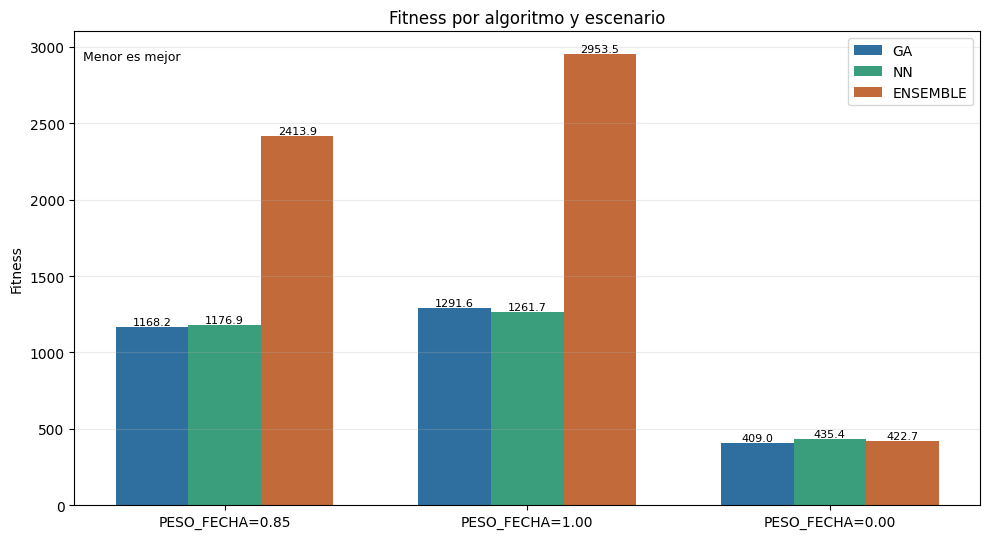

Grafica guardada en: /opt/projects/tfm/algoritmos/output/comparativa_algoritmos/fitness_por_algoritmo.png


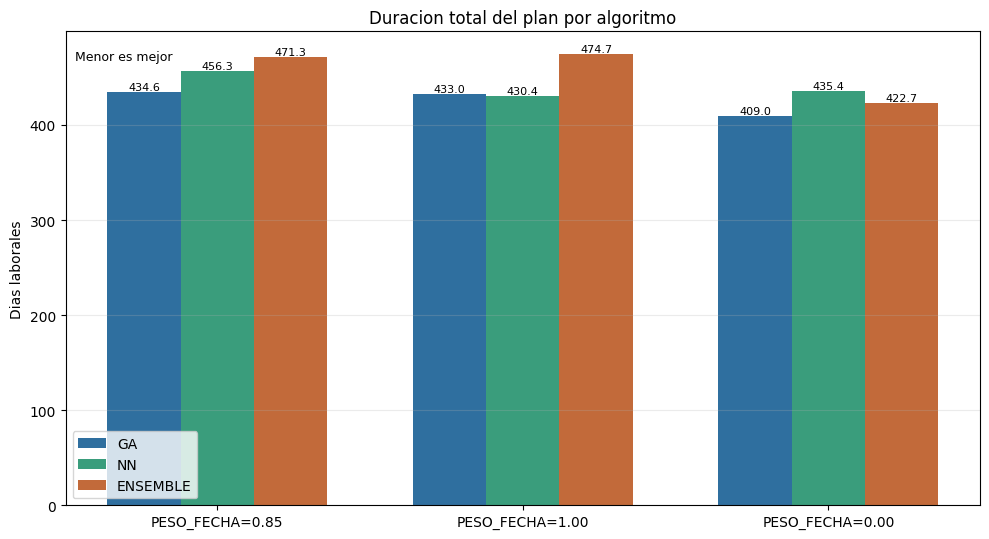

Grafica guardada en: /opt/projects/tfm/algoritmos/output/comparativa_algoritmos/makespan_por_algoritmo.png


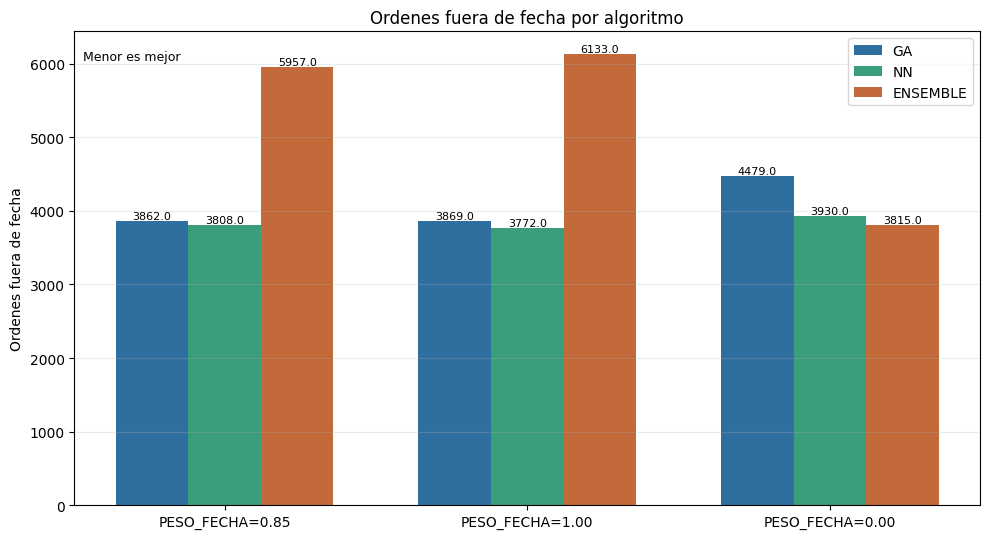

Grafica guardada en: /opt/projects/tfm/algoritmos/output/comparativa_algoritmos/ordenes_tarde_por_algoritmo.png


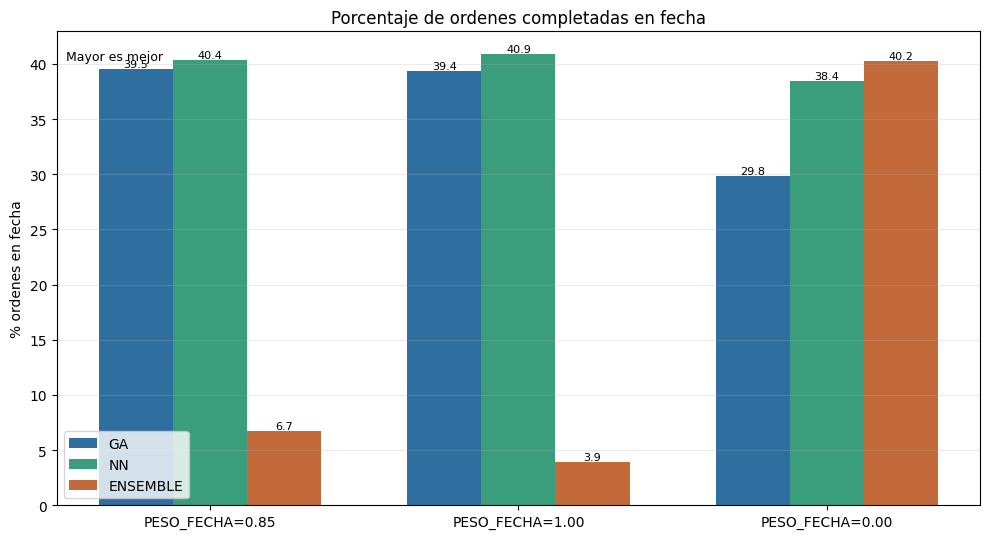

Grafica guardada en: /opt/projects/tfm/algoritmos/output/comparativa_algoritmos/porcentaje_ordenes_en_fecha.png


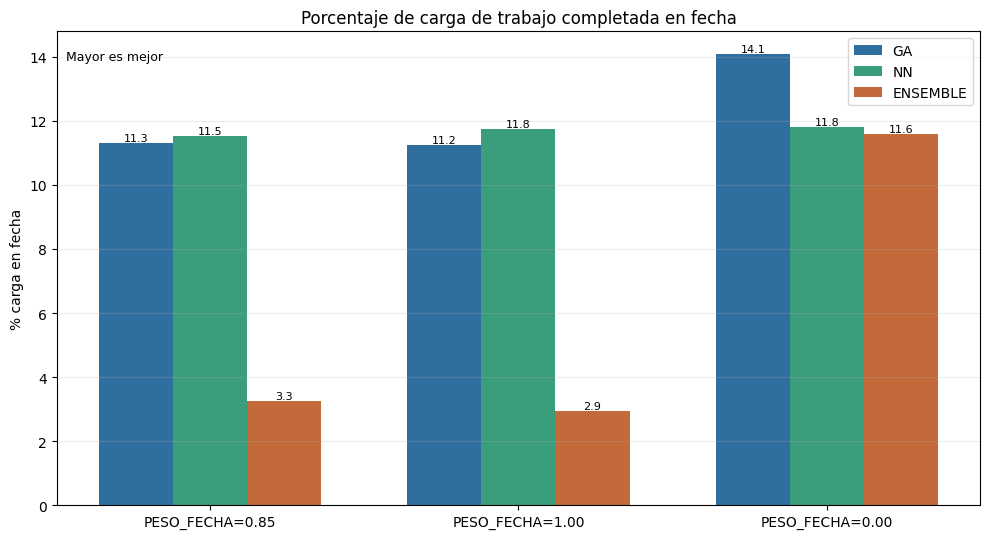

Grafica guardada en: /opt/projects/tfm/algoritmos/output/comparativa_algoritmos/porcentaje_carga_en_fecha.png


: 

In [ ]:
def grouped_bar(df, metric, ylabel, title, filename, lower_is_better=True):
    fig, ax = plt.subplots(figsize=(10, 5.5))
    scenarios = SCENARIO_ORDER
    algs = ALGORITHM_ORDER
    x = np.arange(len(scenarios))
    width = 0.24
    colors = {"GA": "#2f6f9f", "NN": "#3a9d7c", "ENSEMBLE": "#c26a3a"}

    for i, alg in enumerate(algs):
        vals = []
        for scenario in scenarios:
            sub = df[(df["escenario"].astype(str) == scenario) & (df["algoritmo"].astype(str) == alg)]
            vals.append(float(sub[metric].iloc[0]) if len(sub) else np.nan)
        bars = ax.bar(x + (i - 1) * width, vals, width, label=alg, color=colors.get(alg))
        for bar, val in zip(bars, vals):
            if np.isfinite(val):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{val:.1f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([SCENARIO_LABELS[s] for s in scenarios])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    if lower_is_better:
        ax.text(0.01, 0.96, "Menor es mejor", transform=ax.transAxes, ha="left", va="top", fontsize=9)
    else:
        ax.text(0.01, 0.96, "Mayor es mejor", transform=ax.transAxes, ha="left", va="top", fontsize=9)
    fig.tight_layout()
    path = COMPARATIVA_DIR / filename
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Grafica guardada en:", path)


grouped_bar(main_df, "fitness", "Fitness", "Fitness por algoritmo y escenario", "fitness_por_algoritmo.png")
grouped_bar(main_df, "makespan_days", "Dias laborales", "Duracion total del plan por algoritmo", "makespan_por_algoritmo.png")
grouped_bar(main_df, "tardy_orders", "Ordenes fuera de fecha", "Ordenes fuera de fecha por algoritmo", "ordenes_tarde_por_algoritmo.png")
grouped_bar(main_df, "on_time_rate_pct", "% ordenes en fecha", "Porcentaje de ordenes completadas en fecha", "porcentaje_ordenes_en_fecha.png", lower_is_better=False)
grouped_bar(main_df, "on_time_workload_rate_pct", "% carga en fecha", "Porcentaje de carga de trabajo completada en fecha", "porcentaje_carga_en_fecha.png", lower_is_better=False)

## Frontera de compromiso entre fechas y duracion

El siguiente grafico situa cada solucion segun dos dimensiones clave: duracion total del plan y porcentaje de ordenes en fecha. Una solucion deseable estaria hacia la izquierda y hacia arriba: menor makespan y mayor cumplimiento de fechas.

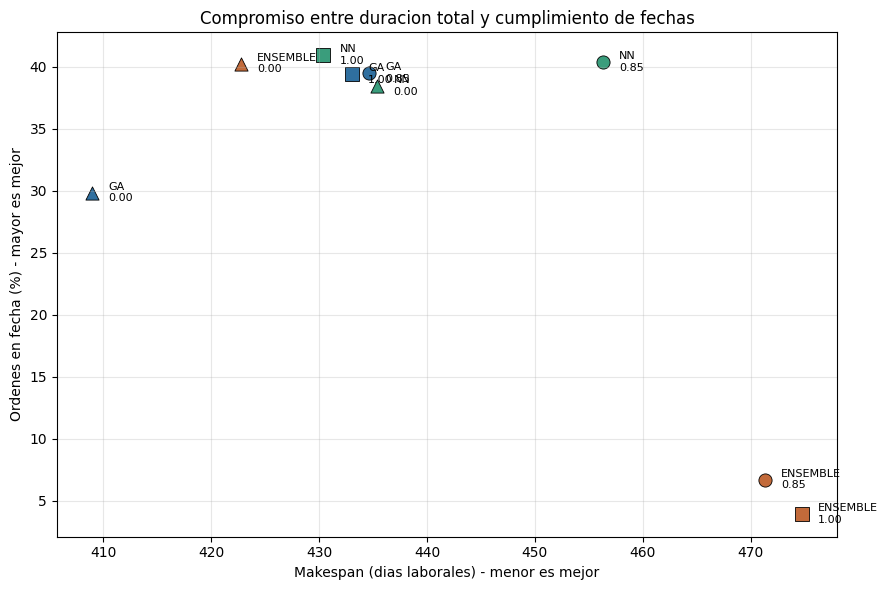

Grafica guardada en: /opt/projects/tfm/algoritmos/output/comparativa_algoritmos/frontera_makespan_vs_cumplimiento.png


: 

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = {"GA": "#2f6f9f", "NN": "#3a9d7c", "ENSEMBLE": "#c26a3a"}
markers = {"inicial": "o", "peso_fecha_1": "s", "peso_fecha_0": "^"}

for _, row in main_df.iterrows():
    ax.scatter(
        row["makespan_days"],
        row["on_time_rate_pct"],
        s=90,
        color=colors.get(str(row["algoritmo"]), "gray"),
        marker=markers.get(str(row["escenario"]), "o"),
        edgecolor="black",
        linewidth=0.6,
    )
    label = f"{row['algoritmo']}\n{row['escenario_label'].split('=')[-1]}"
    ax.text(row["makespan_days"] + 1.5, row["on_time_rate_pct"], label, fontsize=8, va="center")

ax.set_xlabel("Makespan (dias laborales) - menor es mejor")
ax.set_ylabel("Ordenes en fecha (%) - mayor es mejor")
ax.set_title("Compromiso entre duracion total y cumplimiento de fechas")
ax.grid(alpha=0.3)
fig.tight_layout()
path = COMPARATIVA_DIR / "frontera_makespan_vs_cumplimiento.png"
fig.savefig(path, dpi=160, bbox_inches="tight")
plt.show()
print("Grafica guardada en:", path)


## Analisis especifico de la red neuronal

La red neuronal se evalua con dos variantes internas:

- `MLP`: red tabular que aprende la posicion de cada orden en la secuencia del GA a partir de variables agregadas por orden.
- `GNN`: red de grafos que aprende la misma posicion, pero usando ademas la estructura orden-partnumber-operacion-grupo recurso.

Ambas se entrenan con las secuencias ganadoras del algoritmo genetico como profesor.

,escenario_label,variante,fitness,fitness_ga_teacher,tardy_orders,on_time_rate_pct,on_time_workload_rate_pct,makespan_days
0,PESO_FECHA=0.85,MLP,1176.901384,1168.157908,3808,40.350877,11.528505,456.295676
1,PESO_FECHA=0.85,GNN,1204.048651,1168.157908,3930,38.439850,11.557300,430.969138
2,PESO_FECHA=1.00,MLP,1261.655548,1291.640721,3772,40.914787,11.756654,430.391659
3,PESO_FECHA=1.00,GNN,1353.593001,1291.640721,3938,38.314536,11.541869,443.205772
4,PESO_FECHA=0.00,GNN,435.388282,408.997506,3930,38.439850,11.802654,435.388282
5,PESO_FECHA=0.00,MLP,446.715392,408.997506,3938,38.314536,11.523471,446.715392


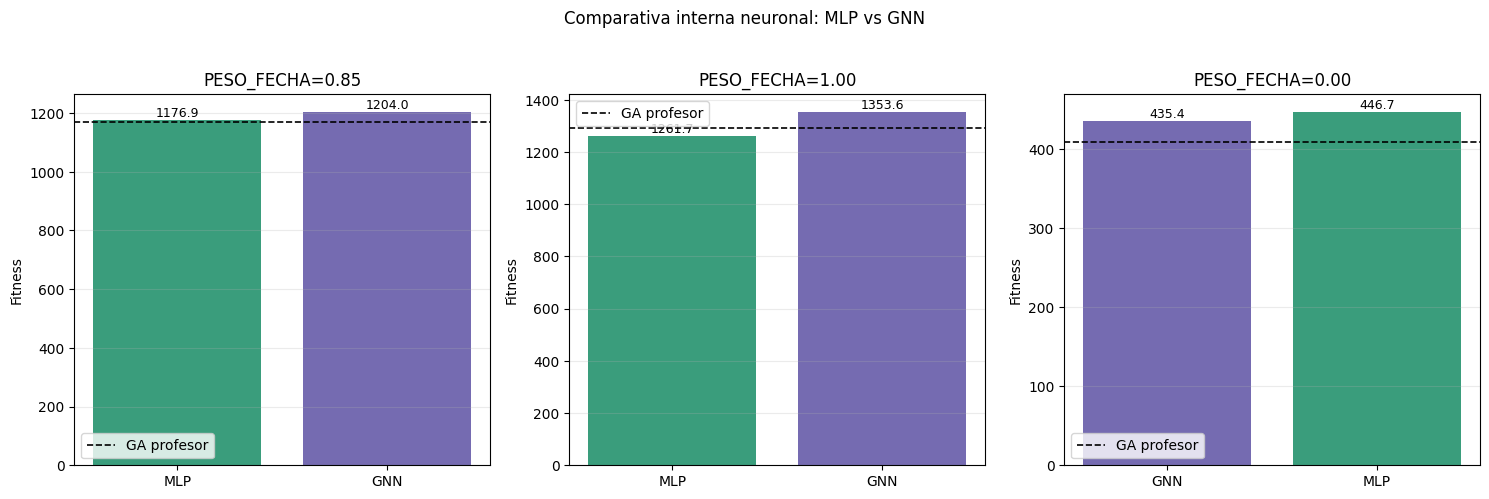

Grafica guardada en: /opt/projects/tfm/algoritmos/output/comparativa_algoritmos/nn_mlp_vs_gnn.png


: 

In [ ]:
display(variant_df[[
    "escenario_label", "variante", "fitness", "fitness_ga_teacher", "tardy_orders",
    "on_time_rate_pct", "on_time_workload_rate_pct", "makespan_days"
]])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=False)
for ax, scenario in zip(axes, SCENARIO_ORDER):
    sub = variant_df[variant_df["escenario"].astype(str) == scenario].copy().sort_values("fitness")
    colors = ["#3a9d7c" if v == "MLP" else "#756bb1" for v in sub["variante"]]
    ax.bar(sub["variante"], sub["fitness"], color=colors)
    teacher = sub["fitness_ga_teacher"].dropna().iloc[0] if sub["fitness_ga_teacher"].notna().any() else None
    if teacher is not None:
        ax.axhline(float(teacher), color="black", linestyle="--", linewidth=1.2, label="GA profesor")
    for x, value in enumerate(sub["fitness"]):
        ax.text(x, value, f"{value:.1f}", ha="center", va="bottom", fontsize=9)
    ax.set_title(SCENARIO_LABELS[scenario])
    ax.set_ylabel("Fitness")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="best")
fig.suptitle("Comparativa interna neuronal: MLP vs GNN", y=1.03)
fig.tight_layout()
path = COMPARATIVA_DIR / "nn_mlp_vs_gnn.png"
fig.savefig(path, dpi=160, bbox_inches="tight")
plt.show()
print("Grafica guardada en:", path)

## Ganadores por escenario

La siguiente tabla resume que algoritmo obtiene el mejor valor para cada criterio principal dentro de cada escenario. Esta tabla es util para redactar conclusiones: no siempre el mejor en `fitness` coincide con el menor `makespan` o el mayor porcentaje de cumplimiento.

In [ ]:
winner_rows = []
for scenario in SCENARIO_ORDER:
    sub = main_df[main_df["escenario"].astype(str) == scenario].copy()
    if not len(sub):
        continue
    checks = [
        ("fitness", "min", "Menor fitness"),
        ("tardy_orders", "min", "Menos ordenes tarde"),
        ("on_time_rate_pct", "max", "Mayor % ordenes en fecha"),
        ("on_time_workload_rate_pct", "max", "Mayor % carga en fecha"),
        ("makespan_days", "min", "Menor makespan"),
        ("total_late_days", "min", "Menor tardanza total"),
    ]
    for metric, mode, label in checks:
        idx = sub[metric].idxmin() if mode == "min" else sub[metric].idxmax()
        row = sub.loc[idx]
        winner_rows.append({
            "escenario": SCENARIO_LABELS[scenario],
            "criterio": label,
            "algoritmo_ganador": row["algoritmo"],
            "variante": row["variante"],
            "valor": row[metric],
        })

winners_df = pd.DataFrame(winner_rows)
display(winners_df)
winners_path = COMPARATIVA_DIR / "ganadores_por_criterio.csv"
winners_df.to_csv(winners_path, sep=";", index=False)
print("Tabla de ganadores guardada en:", winners_path)

,escenario,criterio,algoritmo_ganador,variante,valor
0,PESO_FECHA=0.85,Menor fitness,GA,GA,1168.157908
1,PESO_FECHA=0.85,Menos ordenes tarde,NN,MLP,3808.000000
2,PESO_FECHA=0.85,Mayor % ordenes en fecha,NN,MLP,40.350877
3,PESO_FECHA=0.85,Mayor % carga en fecha,NN,MLP,11.528505
4,PESO_FECHA=0.85,Menor makespan,GA,GA,434.603013
5,PESO_FECHA=0.85,Menor tardanza total,GA,GA,414810.071798
6,PESO_FECHA=1.00,Menor fitness,NN,MLP,1261.655548
7,PESO_FECHA=1.00,Menos ordenes tarde,NN,MLP,3772.000000
8,PESO_FECHA=1.00,Mayor % ordenes en fecha,NN,MLP,40.914787
9,PESO_FECHA=1.00,Mayor % carga en fecha,NN,MLP,11.756654


Tabla de ganadores guardada en: /opt/projects/tfm/algoritmos/output/comparativa_algoritmos/ganadores_por_criterio.csv


: 

## Conclusiones para el TFM

1. **La comparacion es metodologicamente consistente.** Los algoritmos parten de los mismos datos preparados, las mismas duraciones CCP y el mismo decodificador de scheduling. Por tanto, las diferencias observadas se deben principalmente a la politica de secuenciacion de ordenes.

2. **El algoritmo genetico es la referencia mas solida en el escenario principal.** Para `PESO_FECHA = 0.85`, el GA obtiene el mejor fitness global (`1168.16`). La red neuronal queda muy cerca (`1176.90`), con una diferencia pequena respecto al profesor genetico, mientras que el ensemble queda claramente penalizado (`2413.92`).

3. **La red neuronal supervisada por el GA es competitiva.** En el escenario principal, la red mejora ligeramente el numero de ordenes en fecha frente al GA, aunque alarga el makespan. Esto sugiere que la red aprende una aproximacion util de la secuencia genetica, pero no reproduce exactamente el equilibrio global encontrado por el GA.

4. **En el escenario de solo fechas, la red neuronal MLP obtiene el mejor fitness observado.** Para `PESO_FECHA = 1.0`, la MLP neuronal supera al GA profesor en la ejecucion actual. Esta conclusion debe interpretarse como resultado empirico de esta corrida, no como prueba de optimalidad global: la red aproxima el ranking del GA y puede introducir una reordenacion suavizada que, al pasar por el decodificador, mejora la metrica final.

5. **En el escenario de solo duracion, el GA mantiene el mejor makespan.** Para `PESO_FECHA = 0.0`, el GA consigue el menor makespan (`408.99` dias). El ensemble queda relativamente cerca (`422.73`) y la GNN mejora a la MLP dentro del bloque neuronal, aunque no alcanza al GA.

6. **La GNN aporta valor estructural, pero no domina globalmente.** La GNN supera a la MLP en el escenario de menor duracion total, lo que es coherente con la naturaleza de grafo del APS: operaciones, grupos de recurso y rutas compartidas influyen directamente en los cuellos de botella. Sin embargo, la MLP es mejor en los escenarios orientados a fechas, probablemente porque las variables agregadas por orden (`slack`, `cr`, carga CCP y numero de operaciones) capturan ya gran parte de la senal relevante para tardanza.

7. **El ensemble/XGBoost queda como el enfoque menos competitivo en los escenarios con peso de fechas.** Su rendimiento confirma que imitar o ponderar reglas de despacho simples no basta para capturar la complejidad combinatoria del problema cuando el objetivo principal es reducir tardanza.

En conjunto, los resultados apoyan una conclusion clara para el trabajo: el algoritmo genetico es la referencia mas robusta como optimizador combinatorio; la red neuronal supervisada por el GA es una aproximacion prometedora y computacionalmente rapida; la GNN es interesante como extension estructural, especialmente para objetivos de flujo/makespan; y el ensemble basado en reglas queda por detras cuando se evalua el cumplimiento de fechas.

In [ ]:
print("Archivos generados para el informe:")
for path in sorted(COMPARATIVA_DIR.glob("*")):
    print("-", path)

Archivos generados para el informe:
- /opt/projects/tfm/algoritmos/output/comparativa_algoritmos/comparativa_algoritmos_resumen.csv
- /opt/projects/tfm/algoritmos/output/comparativa_algoritmos/comparativa_nn_variantes.csv
- /opt/projects/tfm/algoritmos/output/comparativa_algoritmos/fitness_por_algoritmo.png
- /opt/projects/tfm/algoritmos/output/comparativa_algoritmos/frontera_makespan_vs_cumplimiento.png
- /opt/projects/tfm/algoritmos/output/comparativa_algoritmos/ganadores_por_criterio.csv
- /opt/projects/tfm/algoritmos/output/comparativa_algoritmos/makespan_por_algoritmo.png
- /opt/projects/tfm/algoritmos/output/comparativa_algoritmos/nn_mlp_vs_gnn.png
- /opt/projects/tfm/algoritmos/output/comparativa_algoritmos/ordenes_tarde_por_algoritmo.png
- /opt/projects/tfm/algoritmos/output/comparativa_algoritmos/porcentaje_carga_en_fecha.png
- /opt/projects/tfm/algoritmos/output/comparativa_algoritmos/porcentaje_ordenes_en_fecha.png


: 

## Valoracion final de los algoritmos para este problema

El problema APS tratado aqui es especialmente exigente porque no basta con ordenar una lista de ordenes: cada decision afecta a operaciones encadenadas, grupos de recurso, maquinas alternativas, capacidad finita, calendario laboral, fechas objetivo y acumulacion de tardanza. Por eso, el algoritmo que mejor funciona no es necesariamente el mas rapido ni el mas sofisticado desde el punto de vista de machine learning, sino el que mejor explora el espacio combinatorio respetando las restricciones duras del planificador.

### Algoritmo genetico

El algoritmo genetico es el enfoque mas adecuado como optimizador principal para este caso. Su fortaleza es que trabaja directamente sobre la variable critica del problema: la secuencia de ordenes. Cada individuo representa una posible permutacion, y cada permutacion se evalua pasando por el mismo decodificador APS que asigna operaciones a recursos reales. Esto hace que el fitness mida el resultado completo de planificacion, no una aproximacion aislada.

Sus principales ventajas son:

- Explora muchas secuencias candidatas sin exigir que el problema sea lineal, continuo o diferenciable.
- Tolera bien restricciones complejas: precedencias, recursos alternativos, disponibilidad, calendario laboral y penalizaciones por operaciones no planificadas.
- Optimiza contra metricas finales del plan, como fitness, tardanza, makespan y cumplimiento de fechas.
- Puede mezclar exploracion aleatoria con buenas semillas heuristicas como EDD, SPT y CR.

Su principal debilidad es el coste computacional: evaluar muchas poblaciones requiere decodificar muchos planes completos. Tambien puede depender de parametros como poblacion, generaciones, cruce y mutacion. Aun asi, para este problema esa carga esta justificada porque la calidad de la solucion depende de interacciones globales que las reglas simples no capturan bien.

La evidencia de la comparativa apunta a que el genetico es la mejor referencia global porque obtiene el mejor equilibrio en el escenario principal y mantiene resultados fuertes cuando cambia el peso de la funcion objetivo. En particular, destaca en fitness y makespan, que son medidas globales del plan completo. Esto indica que no solo mejora una regla local, sino que encuentra secuencias que reducen bloqueos y aprovechan mejor la capacidad disponible.

### Ensemble y XGBoost

El enfoque Ensemble/XGBoost es util como baseline inteligente y como metodo rapido de priorizacion, pero es mas limitado como optimizador APS. Su punto fuerte es que convierte variables tabulares de cada orden en un score de prioridad: carga estimada, holgura, criticidad, deadline, numero de operaciones, alternativas y riesgo historico. Esto permite generar secuencias rapidamente y compararlas contra reglas clasicas como SPT, EDD, CR o SLACK.

Sus ventajas son:

- Es rapido una vez construidas las features.
- Es interpretable mediante importancia de variables.
- Sirve para comprobar si reglas de despacho relativamente simples explican bien el problema.
- Puede actuar como generador de buenas soluciones iniciales o como baseline frente al genetico.

Su debilidad principal es que XGBoost aprende un ranking de prioridad, pero no optimiza directamente el plan completo. No ve de forma natural todas las consecuencias futuras de una decision: una orden puede parecer urgente o corta de forma aislada, pero al insertarla en el calendario puede bloquear recursos criticos y empeorar la tardanza total. Por eso, en la comparativa queda por detras en escenarios donde el cumplimiento de fechas y las interacciones entre recursos son importantes.

### Red neuronal MLP/GNN

El enfoque neuronal es prometedor, sobre todo porque aprende del algoritmo genetico. La MLP intenta aproximar el ranking ganador usando features agregadas por orden, mientras que la GNN incorpora ademas relaciones estructurales entre ordenes, partnumbers, operaciones y grupos de recurso. Esto la hace interesante como politica rapida una vez entrenada.

Sus ventajas son:

- Puede imitar parcialmente la politica del genetico con menor coste en inferencia.
- La MLP captura bastante bien senales tabulares como holgura, carga, CR y deadline.
- La GNN representa mejor la naturaleza estructural del problema, especialmente cuellos de botella y recursos compartidos.
- Puede servir como acelerador o aproximador del GA en carteras similares.

Sus debilidades son las propias de una politica aprendida: depende de la calidad del profesor, de la representatividad de los datos y de que las futuras carteras se parezcan a las usadas para entrenar. Ademas, la red no esta optimizando por si misma el calendario completo; predice una prioridad que despues debe pasar por `decode_schedule`. Por eso puede acercarse mucho al GA, e incluso superar alguna metrica puntual, pero no ofrece la misma garantia de busqueda combinatoria global.

### Por que el genetico queda como mejor solucion

La comparativa evidencia que el genetico es el metodo mas robusto para este problema porque actua en el nivel correcto: no predice una duracion, no aplica solo una regla de prioridad y no imita una solucion previa, sino que genera muchas secuencias candidatas y las evalua con el simulador APS completo. Esa evaluacion completa es fundamental en scheduling, porque el coste real de una decision aparece despues de asignar operaciones a recursos y observar sus efectos sobre fechas, colas y makespan.

En resumen:

- El Ensemble/XGBoost es bueno para priorizar y explicar, pero demasiado local para resolver el problema completo.
- La red neuronal es buena para aproximar o acelerar una politica aprendida, pero depende del GA como profesor y no sustituye plenamente la busqueda.
- El genetico es mas lento, pero es el mas completo como optimizador porque evalua soluciones enteras bajo las restricciones reales del APS.

Por eso, tal y como muestran las metricas y las tablas de ganadores, el algoritmo genetico debe considerarse la referencia principal del trabajo: es el que mejor equilibra calidad de planificacion, cumplimiento de restricciones y optimizacion global del calendario.